# Notebook 05 — Modèle de référence : Elastic Net

**Objectif de ce notebook :**
1. Charger `panel_pret_modelisation.parquet` et construire les **fenêtres d'entraînement
   glissantes/extensives** (voir `fenetres.py` et `config.py`), comme au notebook 04
2. Pour **chaque fenêtre**, chercher les meilleurs hyperparamètres de l'Elastic Net **sur la
   validation de cette fenêtre** (jamais de validation croisée aléatoire ici — voir
   explication), puis évaluer sur son test
3. Mettre bout à bout les prédictions de toutes les fenêtres, et évaluer avec le
   **R² hors-échantillon à la Gu, Kelly & Xiu (2020)**
4. Sauvegarder les prédictions de test (pour le notebook 07), le modèle de la dernière
   fenêtre (`.joblib`) et les résultats agrégés, pour la comparaison finale

Ce notebook lit `data/processed/panel_pret_modelisation.parquet`.

## 0. Import des bibliothèques

In [1]:
import pandas as pd
import numpy as np
from sklearn.linear_model import ElasticNet
import joblib
import warnings
import time
import sys
sys.path.append("..")  # pour pouvoir importer config.py, fenetres.py et journal.py, situes a la racine du projet
import config
import fenetres
import journal

config.assurer_dossiers()  # cree data/interim, data/processed, modeles/, outputs/ si absents

pd.set_option('display.max_columns', 20)
pd.set_option('display.width', 120)
warnings.filterwarnings('ignore', category=UserWarning)

## 1. Chargement des données et construction des fenêtres

In [2]:
panel = pd.read_parquet(config.FICHIER_PANEL_MODELISATION)

caracteristiques = config.CARACTERISTIQUES_RETENUES
macro_predicteurs = config.MACRO_PREDICTEURS
predicteurs = config.PREDICTEURS
cible = config.CIBLE

liste_fenetres = fenetres.generer_fenetres(
    panel['annee_mois'].unique(),
    type_fenetre=config.TYPE_FENETRE,
    annees_train_initial=config.ANNEES_TRAIN_INITIAL,
    annees_validation=config.ANNEES_VALIDATION,
    annees_test_par_fenetre=config.ANNEES_TEST_PAR_FENETRE,
)

print(f"Mode : {config.TYPE_FENETRE}")
print(f"{len(liste_fenetres)} fenetres generees\n")
fenetres.resumer_fenetres(liste_fenetres)

Mode : expanding
3 fenetres generees



,fenetre,train_debut,train_fin,n_mois_train,validation_debut,validation_fin,test_debut,test_fin,annee_test
0,0,198002,199712,215,199801,200912,201001,201312,2010-2013
1,1,198002,200112,263,200201,201312,201401,201712,2014-2017
2,2,198002,200512,311,200601,201712,201801,202112,2018-2021


## 2. Le R² hors-échantillon à la Gu, Kelly & Xiu (2020)

Le R² habituel compare les erreurs du modèle à celles d'une prédiction "naïve" égale à la
**moyenne** de `y`. GKX utilisent une version différente, plus stricte pour les rendements
financiers : ils comparent à une prédiction naïve de **zéro** (ce qui revient à supposer
qu'on ne peut rien prédire des rendements, plutôt que de miser sur un retour à la moyenne
historique).

`R²_oos = 1 - Σ(y - ŷ)² / Σ(y²)`

In [3]:
r2_oos = fenetres.r2_oos  # alias local, pour garder les memes noms de variables qu'avant

## 3. Entraînement et recherche d'hyperparamètres, fenêtre par fenêtre

L'Elastic Net a 2 hyperparamètres : `alpha` (force globale de la régularisation) et
`l1_ratio` (équilibre entre Lasso et Ridge). Pour **chaque fenêtre**, on teste la grille de
combinaisons ci-dessous, chacune entraînée sur le `train` de cette fenêtre et évaluée sur sa
`validation` — jamais de validation croisée aléatoire (`cross_val_score` classique), car elle
mélangerait des périodes temporelles différentes et fausserait l'évaluation (voir la
discussion du notebook 03, partie B, sur la fuite de données temporelle). Le meilleur couple
`(alpha, l1_ratio)` de chaque fenêtre est ensuite ré-entraîné sur son train, puis évalué une
seule fois sur son test.

⚠️ Le `test` de chaque fenêtre ne sert **qu'une seule fois**, à la toute fin de chaque
itération, une fois les hyperparamètres déjà choisis via la `validation` de cette même
fenêtre — jamais pour choisir quoi que ce soit.

On garde de côté, à chaque fenêtre, les prédictions sur `train`, `validation` et `test` (pas
seulement leur R²) : c'est ce qui permettra à la section 4 de calculer un R²_oos pooled sur
toutes les fenêtres mises bout à bout, sans avoir à ré-entraîner quoi que ce soit une seconde
fois.

In [4]:
# Parametres SPECIFIQUES a l'Elastic Net, dans config.py (voir sa docstring) :
# change-les LA-BAS, pas ici, pour qu'ils soient aussi correctement enregistres dans le
# journal des experiences (journal.py, notebook 08).
grille_alpha = config.GRILLE_ALPHA_ELASTIC_NET
grille_l1_ratio = config.GRILLE_L1_RATIO_ELASTIC_NET
max_iter = config.MAX_ITER_ELASTIC_NET

debut_entrainement = time.perf_counter()  # chronometre le temps TOTAL, toutes fenetres confondues (voir section 7)

resultats_par_fenetre = []
predictions_toutes_fenetres = []
pool_train = {'y': [], 'pred': []}
pool_validation = {'y': [], 'pred': []}
coefficients_par_fenetre = []  # un dict {predicteur: coefficient} par fenetre -- voir section 6bis
modele_final = None

for f in liste_fenetres:
    donnees = fenetres.preparer_fenetre(panel, f, predicteurs, macro_predicteurs, cible)

    # --- recherche d'hyperparametres sur la validation de CETTE fenetre ---
    recherche = []
    for alpha in grille_alpha:
        for l1_ratio in grille_l1_ratio:
            modele = ElasticNet(alpha=alpha, l1_ratio=l1_ratio, max_iter=max_iter, random_state=0)
            modele.fit(donnees['X_train'], donnees['y_train'])
            score = r2_oos(donnees['y_validation'], modele.predict(donnees['X_validation']))
            recherche.append({'alpha': alpha, 'l1_ratio': l1_ratio, 'r2_oos_validation': score})

    recherche = pd.DataFrame(recherche).sort_values('r2_oos_validation', ascending=False)
    meilleur_alpha = recherche.iloc[0]['alpha']
    meilleur_l1_ratio = recherche.iloc[0]['l1_ratio']

    # --- modele final de cette fenetre, avec les meilleurs hyperparametres ---
    modele = ElasticNet(alpha=meilleur_alpha, l1_ratio=meilleur_l1_ratio, max_iter=max_iter, random_state=0)
    modele.fit(donnees['X_train'], donnees['y_train'])

    pred_train = modele.predict(donnees['X_train'])
    pred_validation = modele.predict(donnees['X_validation'])
    pred_test = modele.predict(donnees['X_test'])

    resultats_par_fenetre.append({
        'fenetre': f['numero'],
        'annee_test': f['annee_test'],
        'n_train': len(donnees['y_train']),
        'alpha': meilleur_alpha,
        'l1_ratio': meilleur_l1_ratio,
        'r2_oos_train': r2_oos(donnees['y_train'], pred_train),
        'r2_oos_validation': r2_oos(donnees['y_validation'], pred_validation),
        'r2_oos_test': r2_oos(donnees['y_test'], pred_test),
    })

    preds = donnees['id_test'].copy()
    preds[cible] = donnees['y_test'].values
    preds['prediction'] = pred_test
    preds['fenetre'] = f['numero']
    predictions_toutes_fenetres.append(preds)

    pool_train['y'].append(donnees['y_train'].values); pool_train['pred'].append(pred_train)
    pool_validation['y'].append(donnees['y_validation'].values); pool_validation['pred'].append(pred_validation)
    coefficients_par_fenetre.append(dict(zip(predicteurs, modele.coef_)))  # voir section 6bis

    modele_final = modele

    print(f"Fenetre {f['numero']:2d} (test {f['annee_test']:>9s}) : "
          f"alpha={meilleur_alpha:.1e}, l1_ratio={meilleur_l1_ratio:.1f} | "
          f"R2_oos test = {resultats_par_fenetre[-1]['r2_oos_test']:.4f}")

duree_entrainement_secondes = time.perf_counter() - debut_entrainement

resultats_par_fenetre = pd.DataFrame(resultats_par_fenetre)
predictions_toutes_fenetres = pd.concat(predictions_toutes_fenetres, ignore_index=True)

print(f"\n{len(resultats_par_fenetre)} fenetres entrainees.")
print(f"Duree totale d'entrainement (toutes fenetres, recherche d'hyperparametres incluse) : "
      f"{duree_entrainement_secondes:.1f} s")

Fenetre  0 (test 2010-2013) : alpha=1.0e-04, l1_ratio=0.3 | R2_oos test = 0.0077
Fenetre  1 (test 2014-2017) : alpha=1.0e-03, l1_ratio=0.5 | R2_oos test = 0.0020
Fenetre  2 (test 2018-2021) : alpha=1.0e-01, l1_ratio=0.9 | R2_oos test = 0.0027

3 fenetres entrainees.
Duree totale d'entrainement (toutes fenetres, recherche d'hyperparametres incluse) : 3318.6 s


## 4. Évaluation hors-échantillon pooled (toutes les fenêtres mises bout à bout)

⚠️ **Pourquoi ne pas juste faire la moyenne des R²_oos par fenêtre ?** Parce que les fenêtres
n'ont pas toutes le même nombre d'observations, et parce que la formule du R²_oos (des sommes
au numérateur et au dénominateur, pas un ratio de moyennes) n'est pas linéaire — une moyenne
simple des R² par fenêtre donnerait un poids disproportionné aux fenêtres les plus courtes ou
aux périodes les plus calmes. La bonne pratique (et celle de Gu, Kelly & Xiu 2020) est de
**mettre toutes les prédictions bout à bout** d'abord, puis de calculer un seul R²_oos sur
cette série complète — c'est exactement ce que permettent `pool_train`, `pool_validation` et
`predictions_toutes_fenetres`, déjà construits dans la boucle ci-dessus.

In [5]:
r2_train = r2_oos(np.concatenate(pool_train['y']), np.concatenate(pool_train['pred']))
r2_validation = r2_oos(np.concatenate(pool_validation['y']), np.concatenate(pool_validation['pred']))
r2_test = r2_oos(predictions_toutes_fenetres[cible], predictions_toutes_fenetres['prediction'])

print(f"R2_oos train      (pooled, toutes fenetres) : {r2_train:.4f}")
print(f"R2_oos validation (pooled, toutes fenetres) : {r2_validation:.4f}")
print(f"R2_oos test       (pooled, toutes fenetres) : {r2_test:.4f}")

R2_oos train      (pooled, toutes fenetres) : 0.0035
R2_oos validation (pooled, toutes fenetres) : 0.0024
R2_oos test       (pooled, toutes fenetres) : 0.0037


## 5. Évolution du R²_oos de test et des hyperparamètres au fil des fenêtres

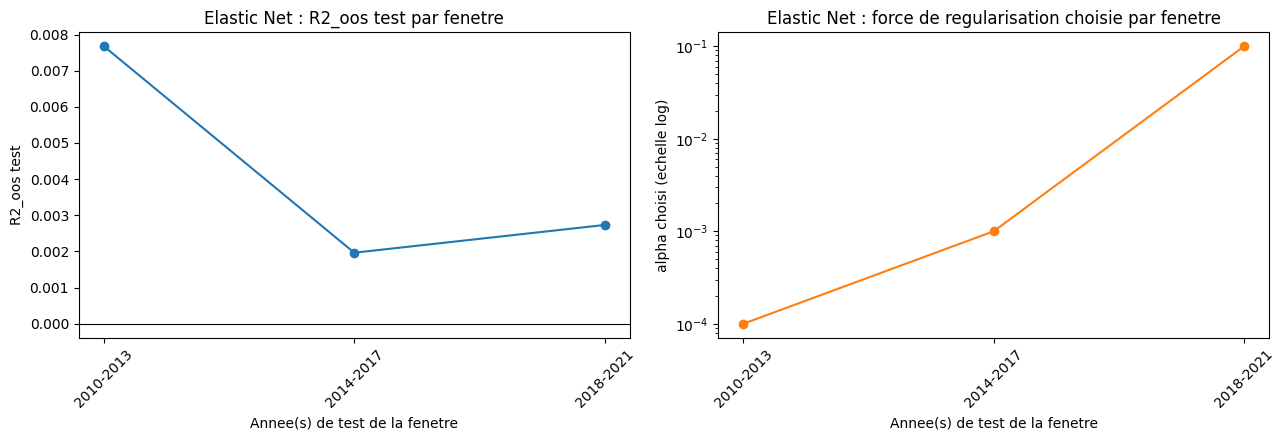

In [6]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

axes[0].plot(resultats_par_fenetre['annee_test'], resultats_par_fenetre['r2_oos_test'], marker='o', color='tab:blue')
axes[0].axhline(0, color='black', linewidth=0.8)
axes[0].set_xlabel("Annee(s) de test de la fenetre")
axes[0].set_ylabel("R2_oos test")
axes[0].set_title("Elastic Net : R2_oos test par fenetre")
axes[0].tick_params(axis='x', rotation=45)

axes[1].plot(resultats_par_fenetre['annee_test'], resultats_par_fenetre['alpha'], marker='o', color='tab:orange')
axes[1].set_yscale('log')
axes[1].set_xlabel("Annee(s) de test de la fenetre")
axes[1].set_ylabel("alpha choisi (echelle log)")
axes[1].set_title("Elastic Net : force de regularisation choisie par fenetre")
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

ℹ️ Si `alpha` varie beaucoup d'une fenêtre à l'autre, c'est un signe que la meilleure force
de régularisation dépend fortement de la période — pas forcément un problème, mais un
diagnostic qu'un unique jeu d'hyperparamètres pour tout le projet ne pourrait pas montrer.

## 6. Coup d'œil rapide aux caractéristiques (modèle de la dernière fenêtre)

L'Elastic Net ramène certains coefficients exactement à 0 (sélection automatique de
variables) — c'est intéressant à regarder, même si ce n'est qu'un modèle de référence. On
regarde ici les coefficients du modèle de la **dernière fenêtre**, celui sauvegardé en
`.joblib` à la section 7 -- un simple instantané. La section 6bis, juste après, agrège la sélection sur **toutes** les fenêtres pour distinguer les variables régulièrement retenues des variables sélectionnées par accident sur une seule période.

In [7]:
coefficients = pd.Series(modele_final.coef_, index=predicteurs).sort_values(key=abs, ascending=False)

nb_a_zero = (coefficients == 0).sum()
print(f"Nombre de variables ramenees exactement a 0 : {nb_a_zero} / {len(predicteurs)}")
print()
print("Top 15 des variables les plus importantes (en valeur absolue) :")
coefficients.head(15)

Nombre de variables ramenees exactement a 0 : 60 / 60

Top 15 des variables les plus importantes (en valeur absolue) :


mvel1         0.0
beta         -0.0
betasq       -0.0
chmom        -0.0
dolvol       -0.0
idiovol      -0.0
indmom        0.0
mom1m        -0.0
mom6m         0.0
mom12m        0.0
mom36m       -0.0
pricedelay   -0.0
turn         -0.0
age           0.0
agr           0.0
dtype: float64

## 6bis. Stabilité de la sélection de variables (stability selection, toutes les fenêtres)

Un coefficient non nul sur la **dernière fenêtre** ne dit rien sur sa **fiabilité** : une
variable peut être retenue une année et ignorée la suivante, simplement parce que la
meilleure combinaison `(alpha, l1_ratio)` a légèrement changé (voir section 5). L'idée de
la **sélection de stabilité** (*stability selection*, Meinshausen & Bühlmann, 2010) est de
regarder, sur **toutes** les fenêtres déjà entraînées (section 3), à quelle fréquence
chaque prédicteur a été gardé (coefficient ≠ 0) plutôt que de se fier à une seule
estimation ponctuelle — l'équivalent, pour un modèle régularisé, de la significativité par
Fama-MacBeth utilisée au notebook 04 pour la régression linéaire (les coefficients de
l'Elastic Net n'ont pas de loi d'échantillonnage classique exploitable pour un test de
significativité au sens habituel, d'où cette approche différente, mieux adaptée).

Pour chaque prédicteur, on calcule :
- **Fréquence de sélection** : % des fenêtres où son coefficient est non nul.
- **Coefficient moyen (fenêtres sélectionnées)** : sa magnitude moyenne, uniquement sur les
  fenêtres où il a été gardé (une moyenne sur toutes les fenêtres, zéros compris, écraserait
  artificiellement les variables rarement sélectionnées).
- **Signe majoritaire** : cohérence du signe d'une fenêtre à l'autre (un signe qui change
  souvent est un signal d'instabilité, même si la fréquence de sélection est élevée).

In [8]:
coefficients_par_fenetre_df = pd.DataFrame(coefficients_par_fenetre, index=resultats_par_fenetre['fenetre'])
print(f"Coefficients sauvegardes pour {len(coefficients_par_fenetre_df)} fenetres x {len(predicteurs)} predicteurs.")

frequence_selection = (coefficients_par_fenetre_df != 0).mean() * 100  # % de fenetres ou coef != 0

def moyenne_si_selectionne(colonne):
    non_nuls = colonne[colonne != 0]
    return non_nuls.mean() if len(non_nuls) > 0 else 0.0

coef_moyen_selectionne = coefficients_par_fenetre_df.apply(moyenne_si_selectionne)

def signe_majoritaire(colonne):
    non_nuls = colonne[colonne != 0]
    if len(non_nuls) == 0:
        return 0
    return 1 if (non_nuls > 0).mean() >= 0.5 else -1

signe_dominant = coefficients_par_fenetre_df.apply(signe_majoritaire)

def pct_accord_signe(colonne):
    non_nuls = colonne[colonne != 0]
    if len(non_nuls) == 0:
        return np.nan
    majorite = 1 if (non_nuls > 0).mean() >= 0.5 else -1
    return (np.sign(non_nuls) == majorite).mean() * 100

coherence_signe = coefficients_par_fenetre_df.apply(pct_accord_signe)

stabilite = pd.DataFrame({
    'frequence_selection_pct': frequence_selection,
    'coef_moyen_si_selectionne': coef_moyen_selectionne,
    'signe_dominant': signe_dominant,
    'coherence_signe_pct': coherence_signe,
}).sort_values(['frequence_selection_pct', 'coef_moyen_si_selectionne'], key=abs, ascending=False)

print(f"\n{(stabilite['frequence_selection_pct'] == 100).sum()} / {len(stabilite)} predicteurs "
      "selectionnes dans TOUTES les fenetres.")
print(f"{(stabilite['frequence_selection_pct'] == 0).sum()} / {len(stabilite)} predicteurs "
      "jamais selectionnes (coefficient toujours ramene a 0).")
print()
print("Top 20 des predicteurs les plus stables (frequence de selection, puis magnitude) :")
stabilite.head(20).round(3)

Coefficients sauvegardes pour 3 fenetres x 60 predicteurs.

0 / 60 predicteurs selectionnes dans TOUTES les fenetres.
11 / 60 predicteurs jamais selectionnes (coefficient toujours ramene a 0).

Top 20 des predicteurs les plus stables (frequence de selection, puis magnitude) :


,frequence_selection_pct,coef_moyen_si_selectionne,signe_dominant,coherence_signe_pct
std_turn,66.667,0.008,1,100.0
turn,66.667,-0.007,-1,100.0
mom12m,66.667,0.006,1,100.0
retvol,66.667,-0.004,-1,100.0
zerotrade,66.667,-0.003,-1,100.0
sp,66.667,0.003,1,100.0
mom1m,66.667,-0.003,-1,100.0
agr,66.667,0.002,1,100.0
indmom,66.667,0.002,1,100.0
roic,66.667,0.002,1,100.0


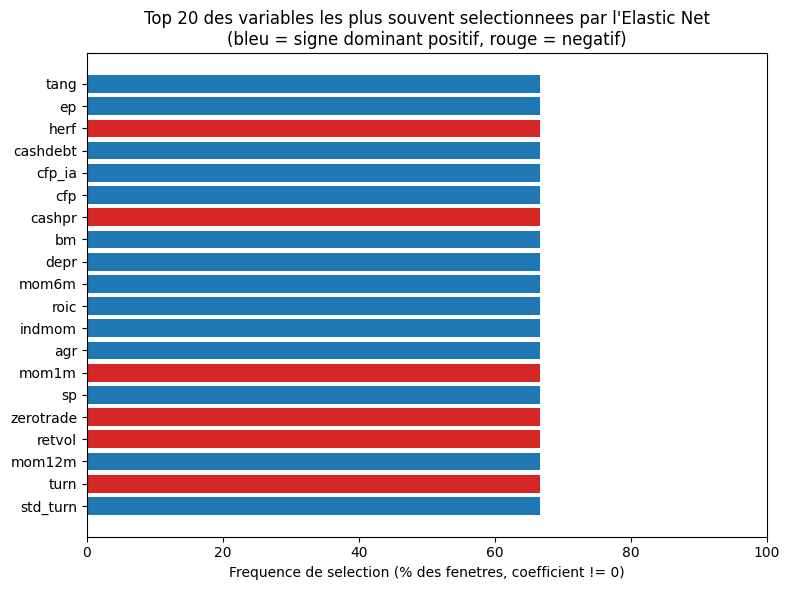

Tableau de stabilite sauvegarde : C:\Users\aless\OneDrive\Documents\Pantheon Sorbonne\cour\Memoire\V11\outputs\importance_elastic_net.parquet


In [9]:
import matplotlib.pyplot as plt

top20_stab = stabilite.head(20).sort_values('frequence_selection_pct')
couleurs = ['tab:blue' if s > 0 else 'tab:red' for s in top20_stab['signe_dominant']]

fig, ax = plt.subplots(figsize=(8, 6))
ax.barh(top20_stab.index, top20_stab['frequence_selection_pct'], color=couleurs)
ax.set_xlim(0, 100)
ax.set_xlabel("Frequence de selection (% des fenetres, coefficient != 0)")
ax.set_title("Top 20 des variables les plus souvent selectionnees par l'Elastic Net\n"
              "(bleu = signe dominant positif, rouge = negatif)")
plt.tight_layout()
plt.show()

stabilite.to_parquet(config.FICHIER_IMPORTANCE_ELASTIC_NET)
print("Tableau de stabilite sauvegarde :", config.FICHIER_IMPORTANCE_ELASTIC_NET)

## 7. Sauvegarde du modèle, des prédictions et des résultats

In [10]:
joblib.dump(modele_final, config.FICHIER_MODELE_ELASTIC_NET)
print("Modele final (derniere fenetre) sauvegarde :", config.FICHIER_MODELE_ELASTIC_NET)

Modele final (derniere fenetre) sauvegarde : C:\Users\aless\OneDrive\Documents\Pantheon Sorbonne\cour\Memoire\V11\modeles\elastic_net.joblib


In [11]:
predictions_toutes_fenetres.to_parquet(config.FICHIER_PREDICTIONS_ELASTIC_NET, index=False)
print("Predictions (toutes fenetres) sauvegardees :", config.FICHIER_PREDICTIONS_ELASTIC_NET)
predictions_toutes_fenetres.head()

Predictions (toutes fenetres) sauvegardees : C:\Users\aless\OneDrive\Documents\Pantheon Sorbonne\cour\Memoire\V11\outputs\predictions_elastic_net.parquet


,permno,annee_mois,excess_return,prediction,fenetre
0,10001,201001,-0.018932,0.004727,0
1,10002,201001,0.365854,-0.009660,0
2,10025,201001,-0.088036,0.008588,0
3,10026,201001,0.046296,-0.000281,0
4,10032,201001,0.194171,0.016283,0


In [ ]:
# Parametres SPECIFIQUES a l'Elastic Net (definis ici, AVANT resultats_finaux, pour etre
# reutilises tels quels a la fois pour la cle_experience ci-dessous et pour
# journal.enregistrer_experience en section 8 -- garantit la meme cle aux deux endroits).
params_specifiques = {
    'grille_alpha': grille_alpha,
    'grille_l1_ratio': grille_l1_ratio,
    'max_iter': max_iter,
}

# Cle d'unicite de CETTE experience -- voir notebook 04, section 7, pour le detail complet
# de ce que ca permet de relier au notebook 07 (portefeuilles) et au notebook 08 (Sharpe...).
cle_experience = journal.cle_experience_actuelle('Elastic Net', params_specifiques)

resultats_finaux = pd.DataFrame([{
    'modele': 'Elastic Net',
    'type_fenetre': config.TYPE_FENETRE,
    'n_fenetres': len(liste_fenetres),
    'r2_oos_train': r2_train,
    'r2_oos_validation': r2_validation,
    'r2_oos_test': r2_test,
    'cle_experience': cle_experience,
}])

resultats_finaux.to_parquet(config.FICHIER_RESULTATS_ELASTIC_NET, index=False)
resultats_par_fenetre.to_parquet(config.FICHIER_RESULTATS_ELASTIC_NET_PAR_FENETRE, index=False)

print("Resultats pooled sauvegardes      :", config.FICHIER_RESULTATS_ELASTIC_NET)
print("Resultats par fenetre sauvegardes :", config.FICHIER_RESULTATS_ELASTIC_NET_PAR_FENETRE)
resultats_finaux

## 8. Enregistrement dans le journal des experiences (notebook 08)

Comme pour la régression linéaire, on ajoute une ligne au **journal des expériences**
(`outputs/journal_experiences.parquet`, jamais écrasé, voir `journal.py`) : ici, les
paramètres **spécifiques** sont `grille_alpha`, `grille_l1_ratio` et `max_iter` (propres
à l'Elastic Net, déjà rassemblés dans `params_specifiques` en section 7, réutilisé tel
quel ci-dessous) -- deux lancements avec la même grille mais un `TYPE_FENETRE` différent
apparaîtront comme deux lignes d'un **même** tableau au notebook 08 ; deux lancements avec
des grilles différentes donneront deux tableaux distincts.

⚠️ **A noter** : `resultats_finaux` (section 7) inclut une colonne
`cle_experience` (voir `journal.cle_experience_actuelle`), reprise par le notebook 07 pour
relier le Sharpe/Sortino/... de **ce** lancement à la bonne ligne du tableau du notebook 08.

In [ ]:
journal.enregistrer_experience(
    modele='Elastic Net',
    params_specifiques=params_specifiques,  # meme variable qu'en section 7 (garantit la
                                             # MEME cle_experience que resultats_finaux)
    resultats={
        'n_fenetres': len(liste_fenetres),
        'r2_oos_train': r2_train,
        'r2_oos_validation': r2_validation,
        'r2_oos_test': r2_test,
    },
    duree_entrainement_secondes=duree_entrainement_secondes,
)

## 9. Résumé et prochaines étapes

- Hyperparamètres (`alpha`, `l1_ratio`) choisis par recherche sur grille, ré-évalués **à
  chaque fenêtre** sur sa propre `validation` (jamais de validation croisée aléatoire, jamais
  sur `test`).
- Même métrique (`R²_oos` à la GKX, pooled sur toutes les fenêtres) et même logique de
  fenêtres que la régression linéaire (notebook 04), pour une comparaison équitable.
- Modèle de la dernière fenêtre sauvegardé dans `modeles/elastic_net.joblib`.
- Prédictions pooled sauvegardées dans `outputs/predictions_elastic_net.parquet`.
- Résultats (pooled + par fenêtre, avec les hyperparamètres choisis à chaque fois) sauvegardés
  dans `outputs/resultats_elastic_net*.parquet`.
- **Stabilité de la sélection de variables (section 6bis)** : fréquence de sélection,
  magnitude moyenne et cohérence de signe de chaque prédicteur, agrégées sur **toutes**
  les fenêtres (pas seulement la dernière) — sauvegardée dans
  `outputs/importance_elastic_net.parquet`.
- Expérience ajoutée à `outputs/journal_experiences.parquet` (sans doublon), regroupée avec les
  autres lancements utilisant la même grille d'hyperparamètres -- voir le notebook 08.
